In [1]:
!pip install mysql-connector-python

In [2]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Establish the connection to the MySQL server
connection = mysql.connector.connect(
    host="localhost",        # Use "127.0.0.1" if localhost causes a connection error
    user="root",            # Your MySQL Workbench username
    password="Anikac@24",# Your MySQL Workbench password
    database="banking" # Optional: The schema/database name you want to use
)

if connection.is_connected():
    print("Successfully connected to the MySQL database!")

Successfully connected to the MySQL database!


In [3]:
query = "select * from banking.customer"

In [4]:
df= pd.read_sql(query, connection)

C:\Users\hp\AppData\Local\Temp\ipykernel_27896\576324542.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df= pd.read_sql(query, connection)


In [5]:
connection.close()

In [6]:
print(df)

     ï»¿Client ID              Name  Age  Location ID Joined Bank  \
0        IND81288     Raymond Mills   24        34324  06-05-2019   
1        IND65833     Julia Spencer   23        42205  10-12-2001   
2        IND47499    Stephen Murray   27         7314  25-01-2010   
3        IND72498    Virginia Garza   40        34594  28-03-2019   
4        IND60181   Melissa Sanders   46        41269  20-07-2012   
...           ...               ...  ...          ...         ...   
2995     IND66827         Earl Hall   82         8760  09-10-2014   
2996     IND40556  Billy Williamson   44        32837  05-02-2009   
2997     IND72414      Victor Black   70        36088  29-12-2009   
2998     IND46652       Andrew Ford   56        24871  13-02-2006   
2999     IND40216        Amy Nguyen   79        38518  08-12-2005   

          Banking Contact Nationality                     Occupation  \
0          Anthony Torres    American           Safety Technician IV   
1        Jonathan Hawkins  

## Exploratory Data Analysis

In [14]:
df.head()

,ï»¿Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [16]:
df.shape

(3000, 25)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ï»¿Client ID              3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [20]:
df.isnull().sum()

ï»¿Client ID                0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

Generating Descriptive Statistics

In [23]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [25]:
bins = [0, 100000, 300000, float('inf')]
labels = ['Low','Medium','High']

df['Income Band']= pd.cut(df['Estimated Income'],bins=bins, labels= labels, right= False)

float('inf') represents positive infinity, which acts as an upper numerical boundary with no limit. Using float('inf') ensures that no data point is left out. Any extremely large number in your dataset will automatically fall into the 'High' category without throwing an error or requiring you to guess a hard maximum value.

right=False means that the right edge of each bin interval is open (excluded) while the left edge is closed (included).

In [28]:
df[['Estimated Income','Income Band']]

,Estimated Income,Income Band
0,75384.77,Low
1,289834.31,Medium
2,169935.23,Medium
3,356808.11,High
4,130711.68,Medium
...,...,...
2995,297617.14,Medium
2996,42397.46,Low
2997,48339.88,Low
2998,107265.87,Medium


<Axes: xlabel='Income Band'>

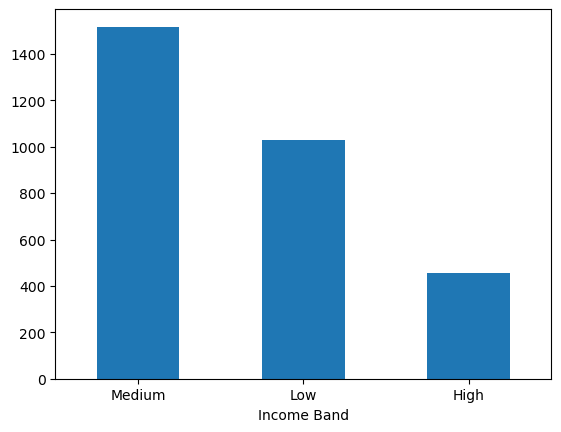

In [30]:
df['Income Band'].value_counts().plot(kind='bar', rot = 0)

Automatic Sorting: Because value_counts() automatically sorts from highest to lowest frequency, your resulting bar chart will also be perfectly ordered from the tallest bar to the shortest bar.
Clean Labels: Pandas automatically uses the unique categories (like 'Low', 'Med', 'High') as the labels for the x-axis.

In [33]:
annuation_bins= [0,25000,50000, float('inf')]
lables = ['Low','Medium','High']

df['Annuation']= pd.cut(df['Superannuation Savings'], bins= annuation_bins, labels = labels, right = False)
                 

<Axes: xlabel='Annuation'>

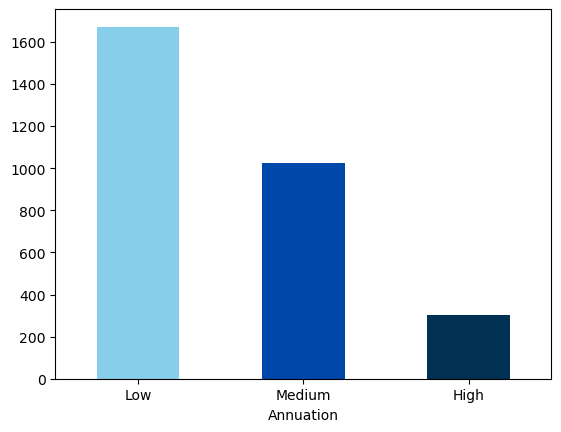

In [35]:
df['Annuation']. value_counts().plot(kind='bar', rot= 0,  color=['skyblue', '#0047AB', '#003153'])


 Value Counts for:'BRId':


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64

<Axes: xlabel='BRId'>


 Value Counts for:'GenderId':


GenderId
2    1512
1    1488
Name: count, dtype: int64

...

Risk Weighting
2    1222
1     836
3     460
4     322
5     160
Name: count, dtype: int64

<Axes: xlabel='Risk Weighting'>


 Value Counts for:'Income Band':


Income Band
Medium    1517
Low       1027
High       456
Name: count, dtype: int64

<Axes: xlabel='Income Band'>

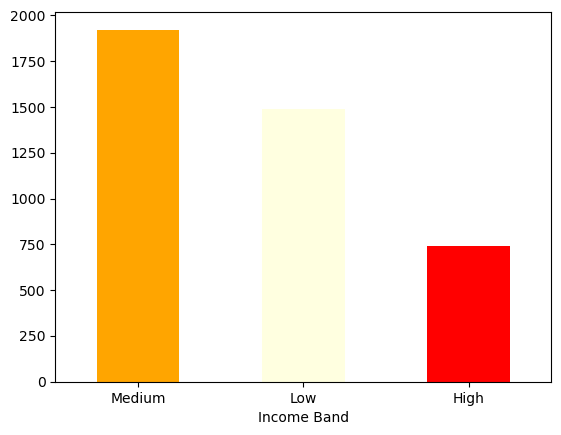

In [47]:
##Examine the distribution of unique categories in categorical columns
categorical_cols = df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", 
                       "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns

for i in categorical_cols:
    print(f"\n Value Counts for:'{i}':")
    display(df[i].value_counts())
    display(df[i].value_counts().plot(kind='bar', rot=0, color=['orange','lightyellow','red']))

In [37]:
df.columns

Index(['ï»¿Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId', 'Income Band',
       'Annuation'],
      dtype='object')

In [39]:
df= df.rename(columns= {'ï»¿Client ID':'Client ID'})

In [41]:
df['Joined Bank']= pd.to_datetime(df['Joined Bank'], format='%d-%m-%Y')
print(df['Joined Bank'].dtype)
                                  

datetime64[ns]


# UNIVARIANT ANALYSIS

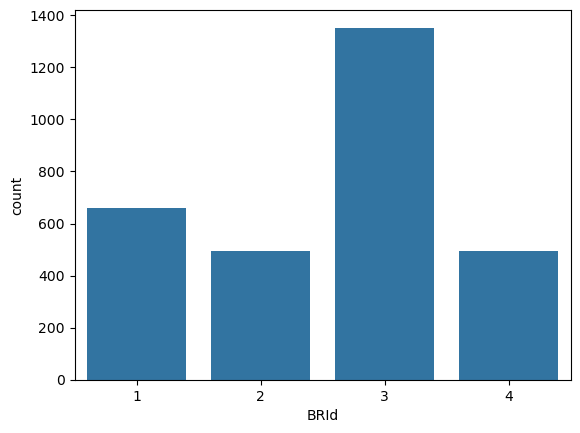

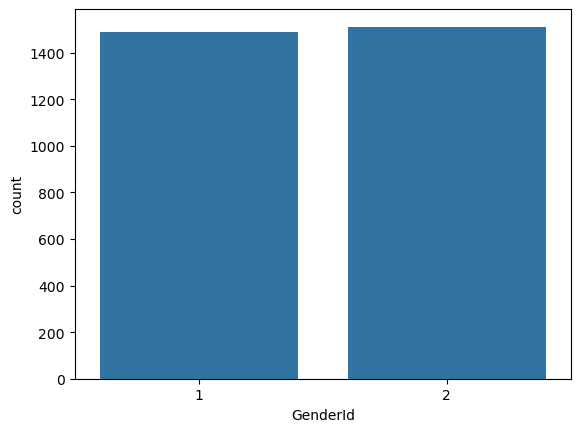

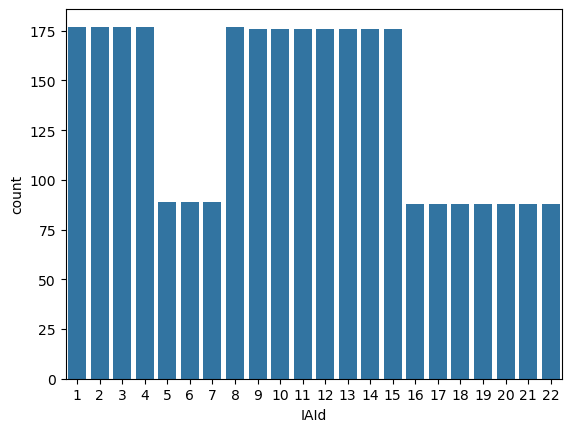

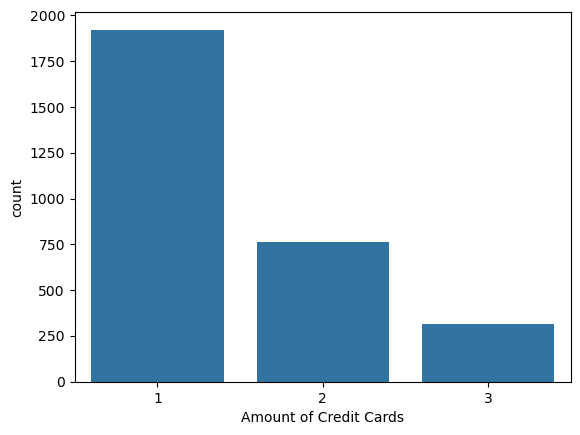

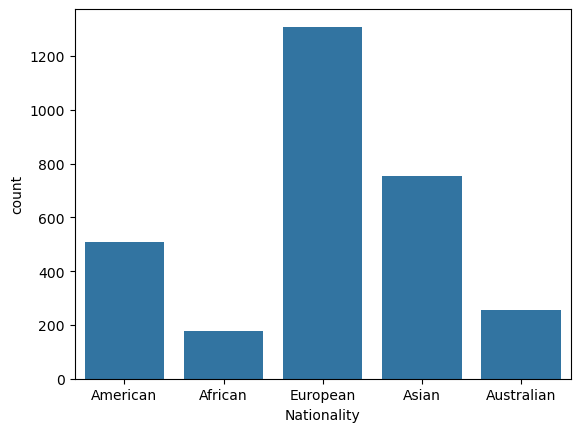

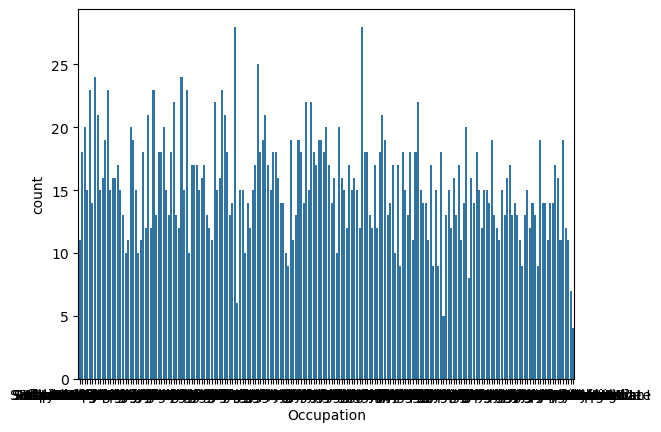

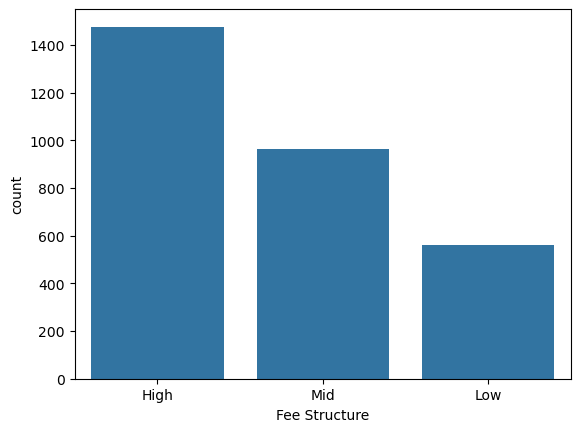

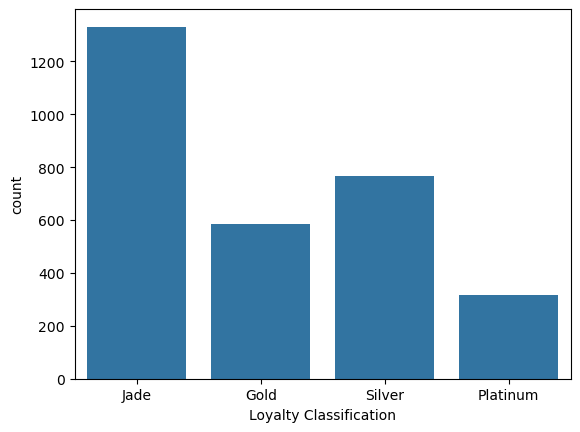

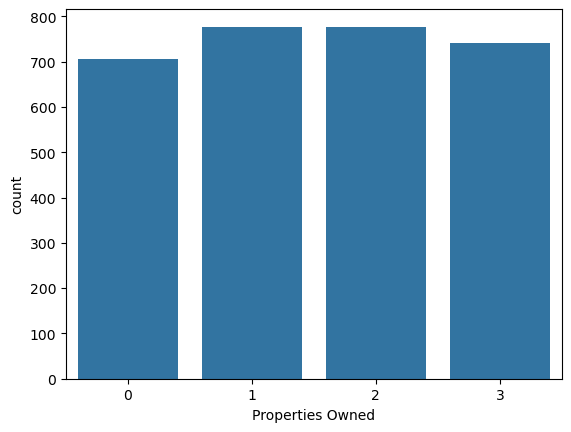

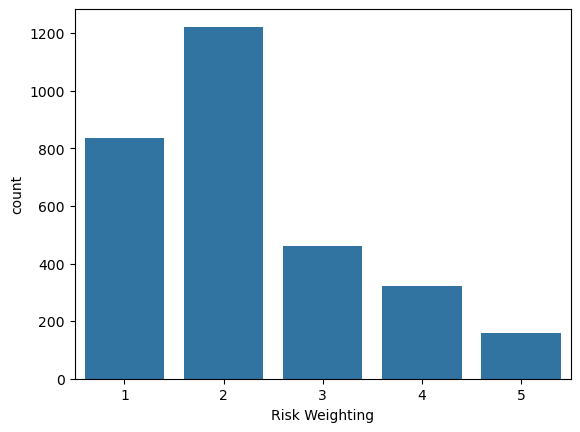

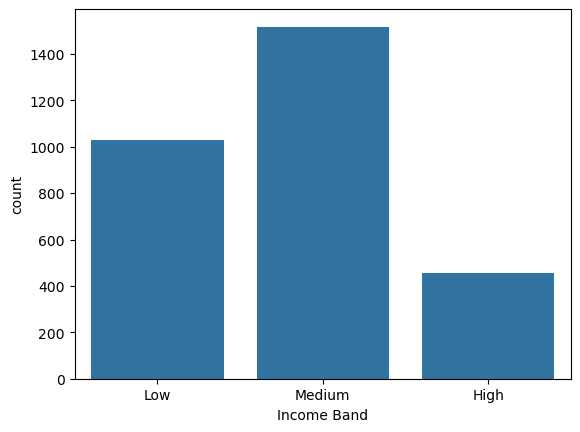

In [44]:
for i, predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", "Occupation", 
                       "Fee Structure", "Loyalty Classification", "Properties Owned", "Risk Weighting", "Income Band"]].columns):
    plt.figure(i)
    sns.countplot(data= df, x = predictor)


enumerate() is a built-in Python function that acts as an automatic counter.When you loop through a list of items, enumerate() keeps track of both the index (the position number) and the item itself at the same time.

For the same code, if add hue= 'Gender Id' in countplot,then it will generate graphs for bivariant analysis.

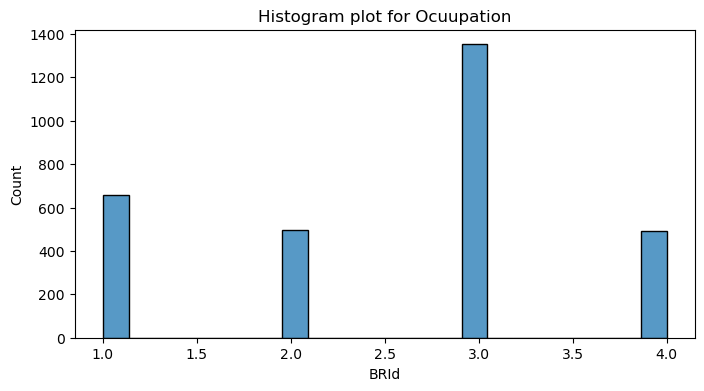

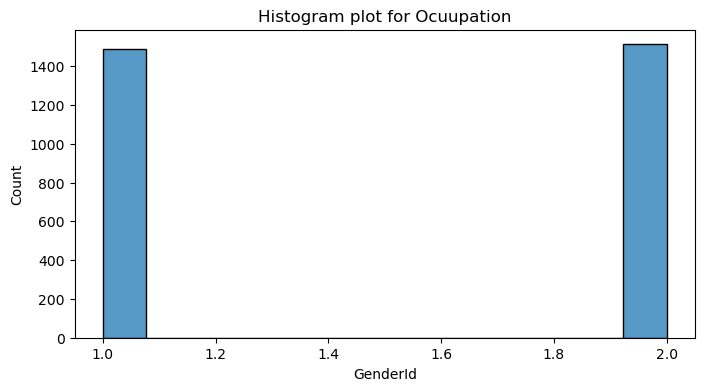

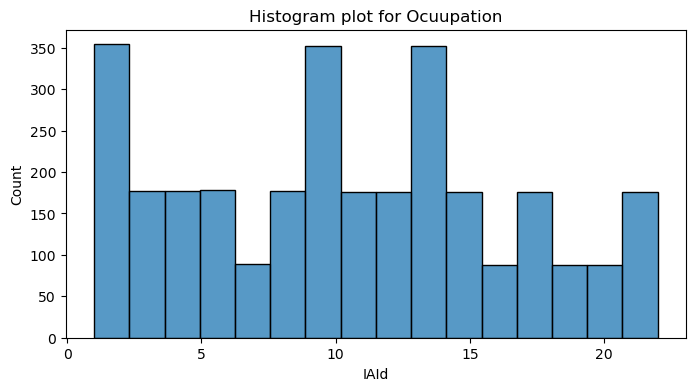

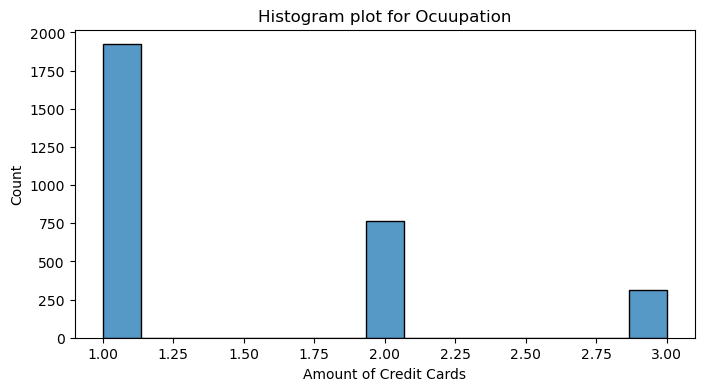

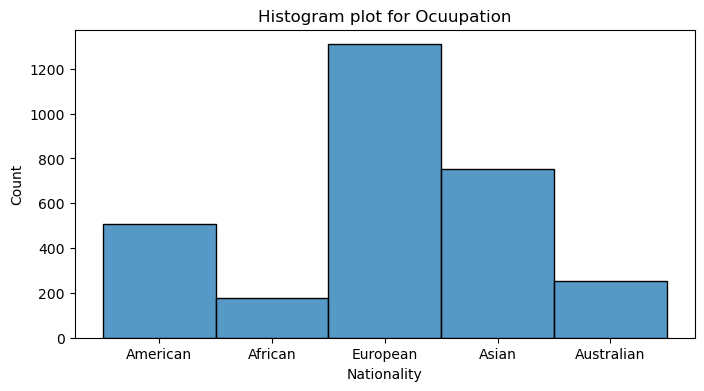

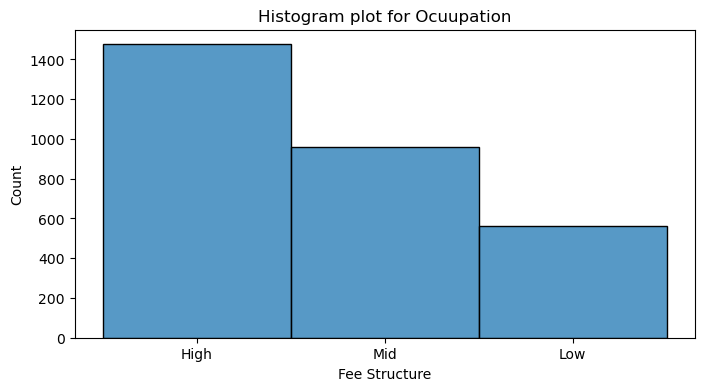

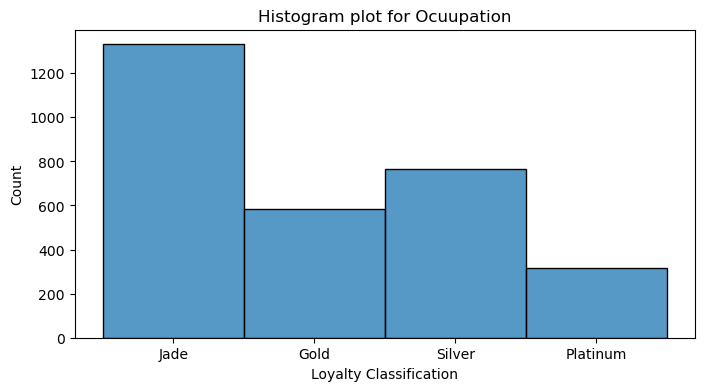

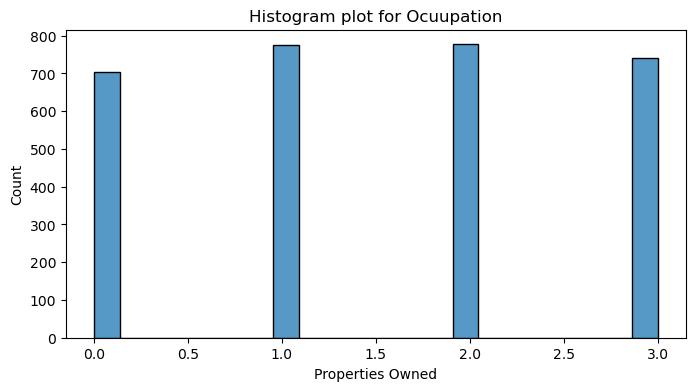

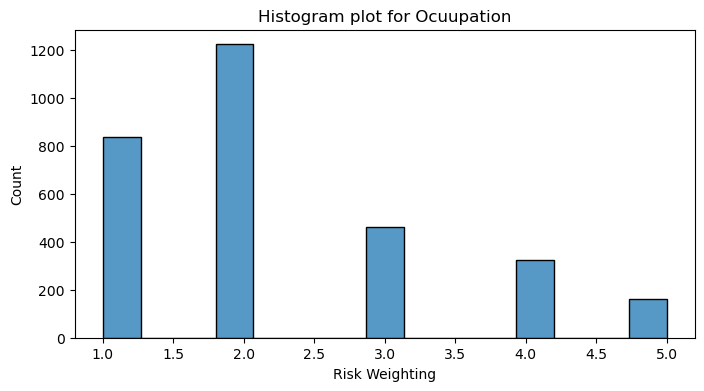

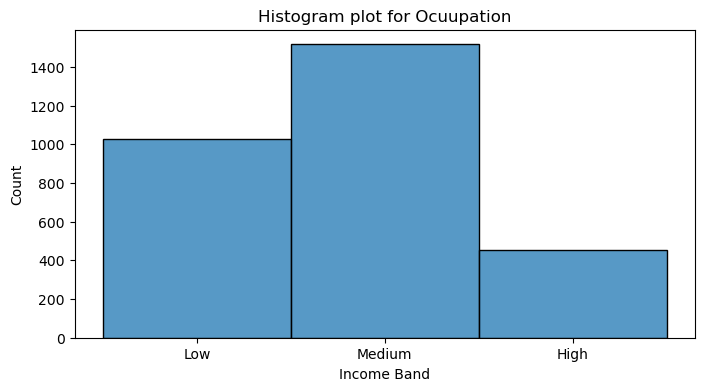

In [63]:
## Histplot for categorical columns.

for x in categorical_cols:
    if x == 'Occupation':
        continue
    plt.figure(figsize=(8,4))
    sns.histplot(df[x])
    plt.title('Histogram plot for Ocuupation')
    plt.xlabel(x)
    plt.ylabel("Count")
    plt.show()

## Numerical Analysis

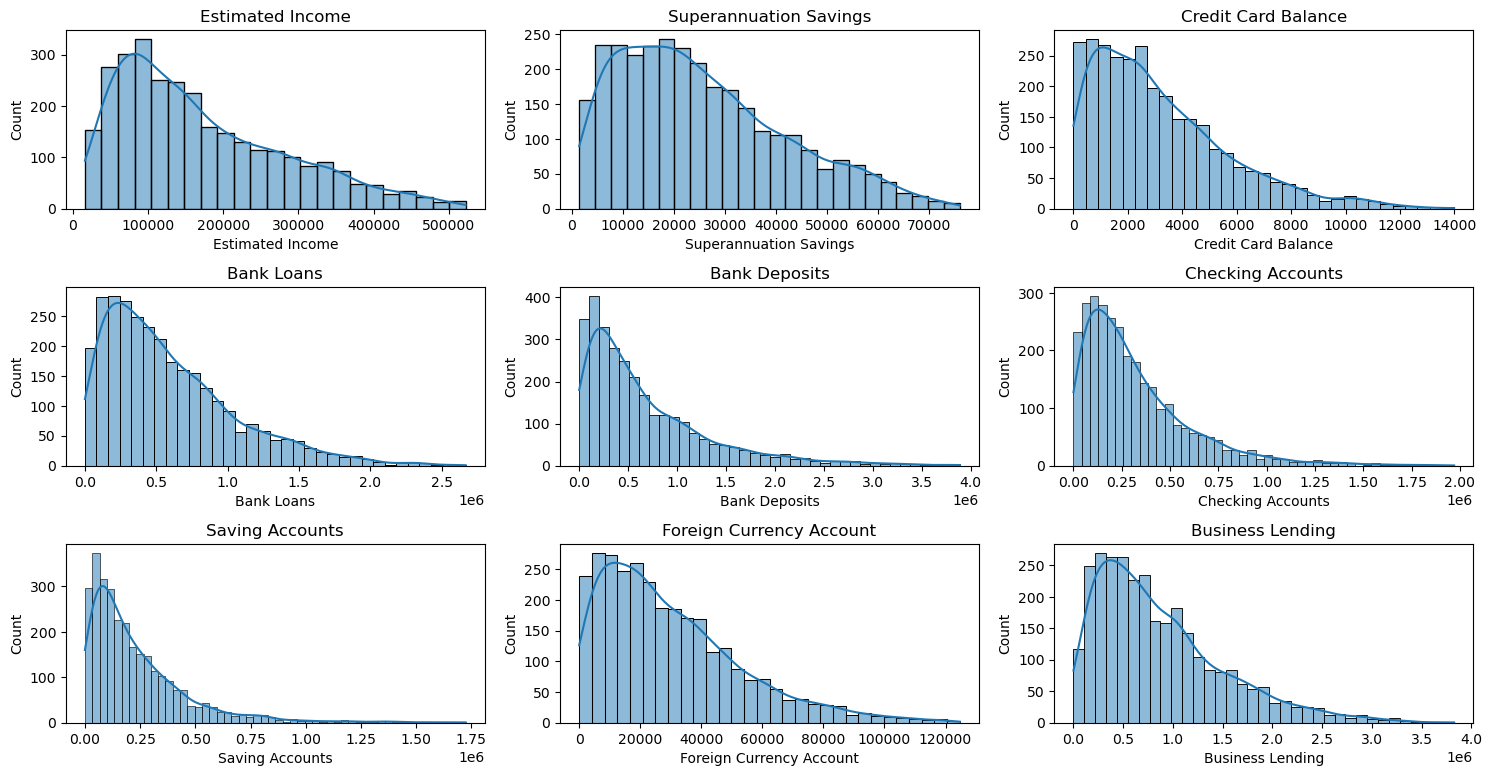

In [46]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 
                  'Saving Accounts', 'Foreign Currency Account', 'Business Lending']
plt.figure(figsize=(15,10))
for i, col in enumerate (numerical_cols):
    plt.subplot(4,3,i+1)
    sns.histplot(df[col], kde= True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [48]:
df.drop(columns='Amount of Credit Cards', inplace = True)

In [50]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Credit Card Balance', 'Bank Loans', 'Bank Deposits',
       'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account',
       'Business Lending', 'Properties Owned', 'Risk Weighting', 'BRId',
       'GenderId', 'IAId', 'Income Band', 'Annuation'],
      dtype='object')

## Heatmap

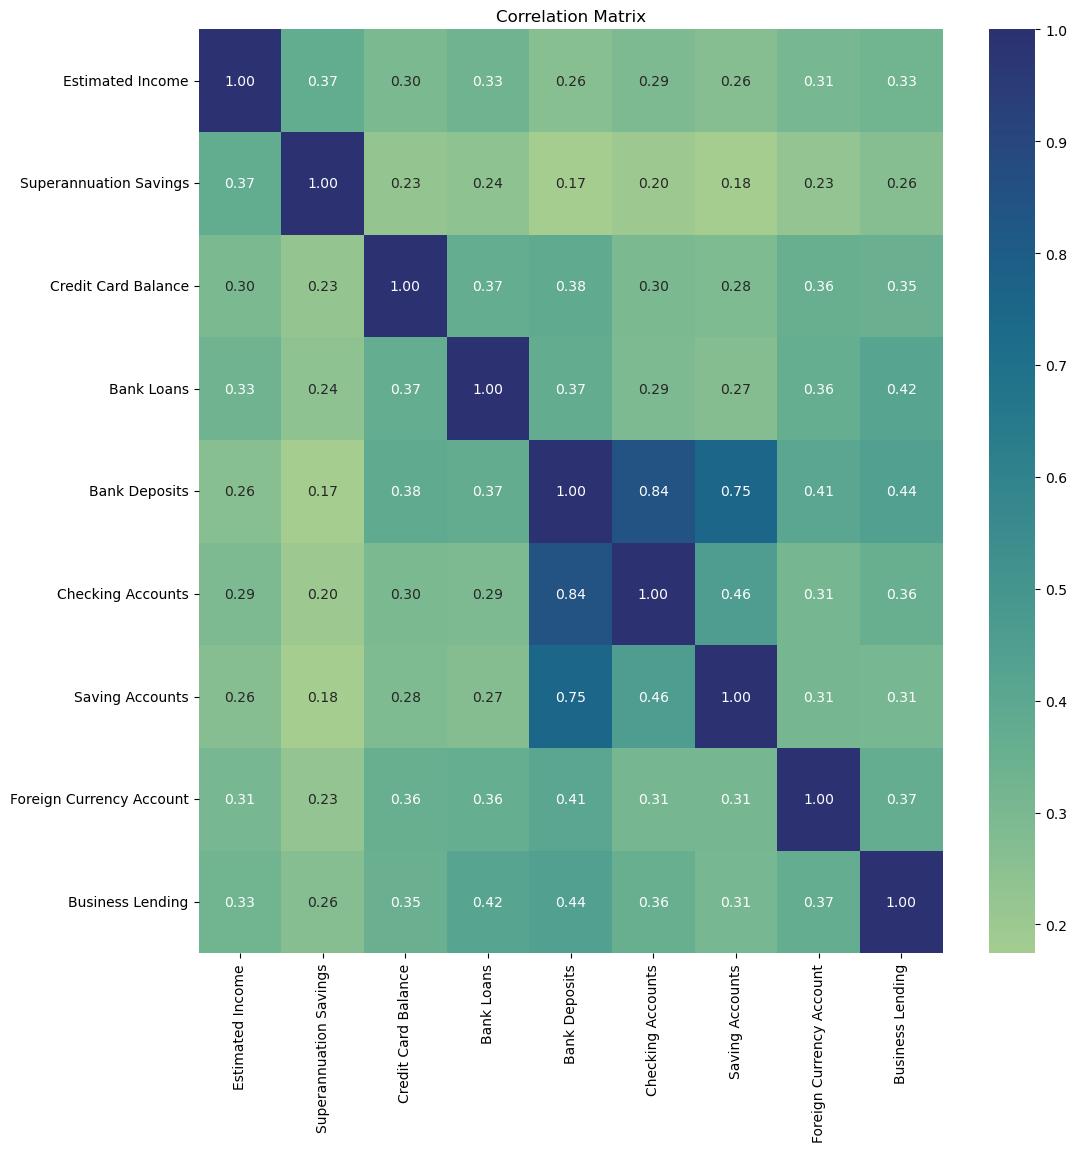

In [53]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 
                  'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,12))
sns.heatmap(corr_matrix,annot=True, cmap='crest', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

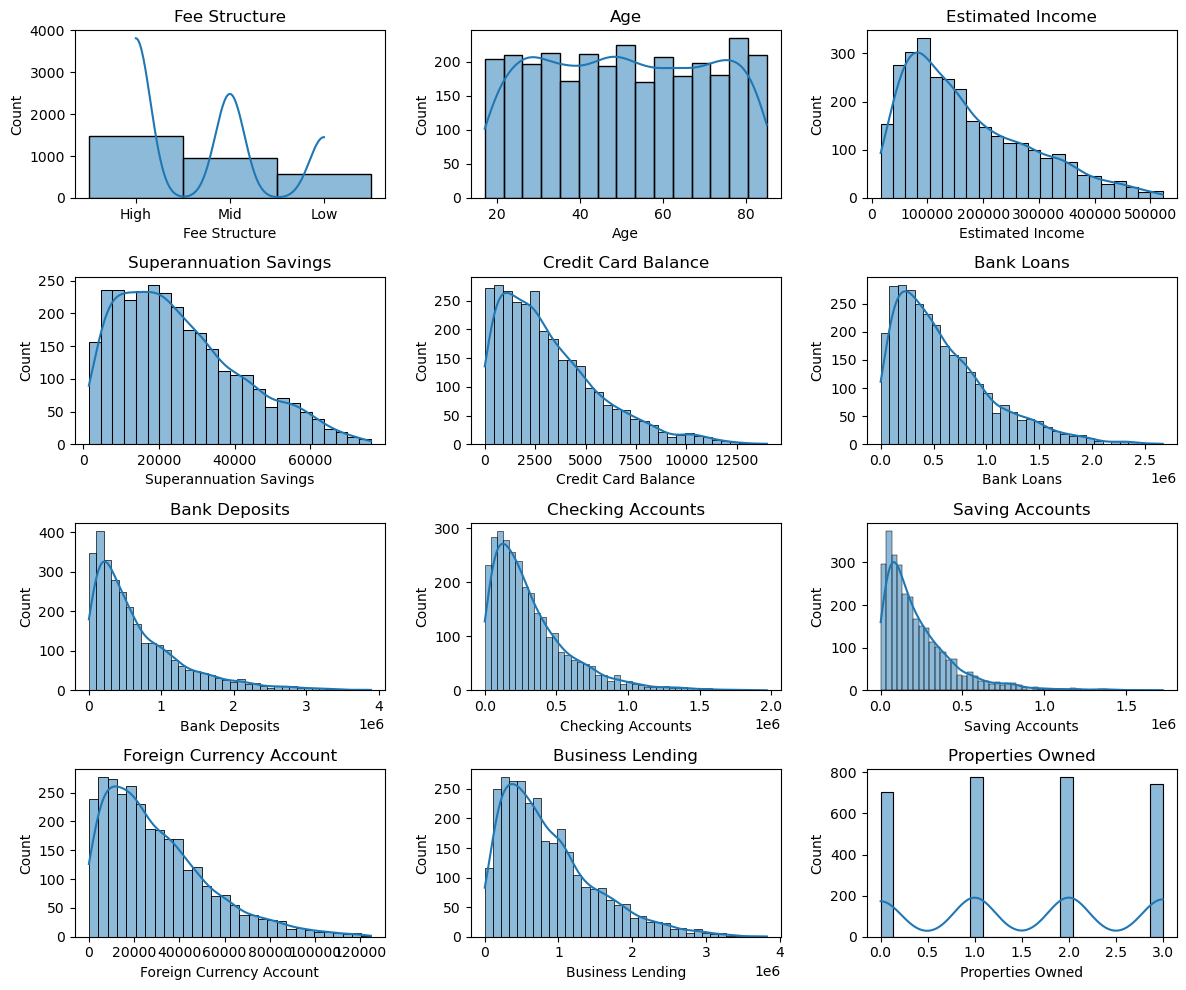

In [55]:
numerical_cols = ['Fee Structure','Age', 'Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 
                  'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending','Properties Owned']

plt.figure(figsize = (12,10))

for i, cols in enumerate(numerical_cols):
    plt.subplot(4,3,i+1)
    sns.histplot(df[cols], kde= True)
    plt.title(cols)
plt.tight_layout()
plt.show()
    
           



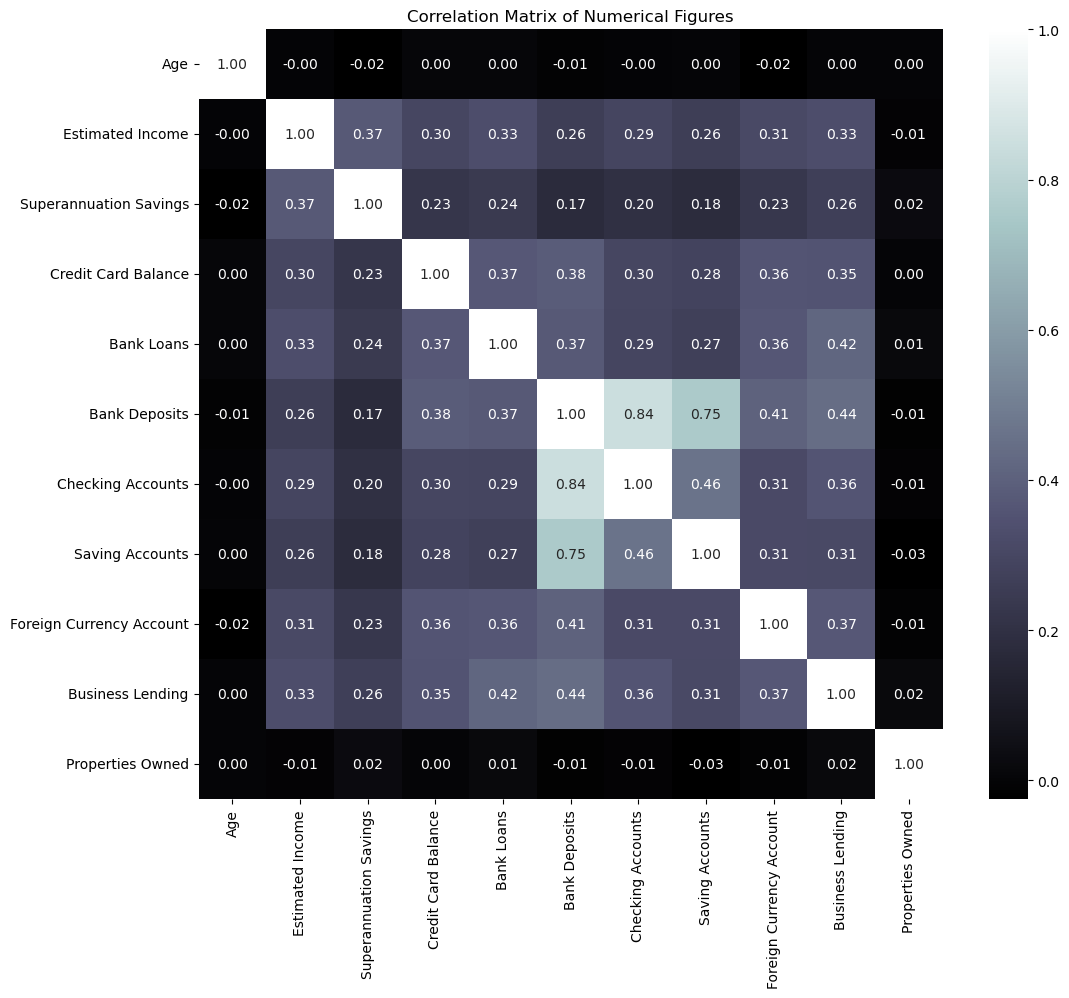

In [93]:
numerical_cols = ['Age', 'Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 
                  'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending','Properties Owned']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot = True, cmap = 'bone', fmt=".2f")
plt.title('Correlation Matrix of Numerical Figures')
plt.show()


## Some More Insights and Analysis

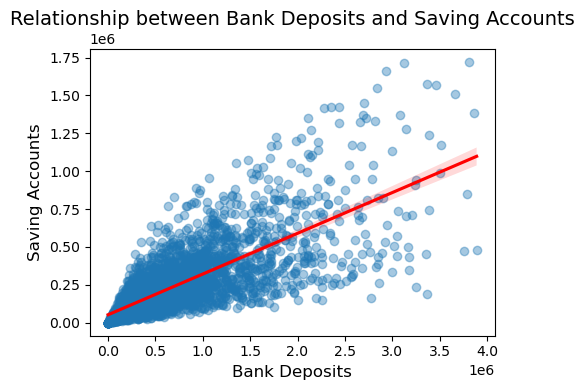

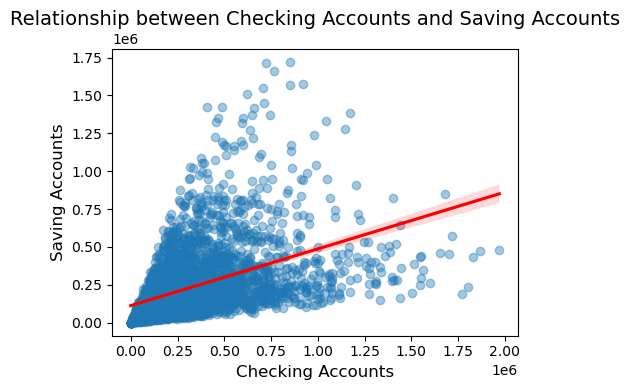

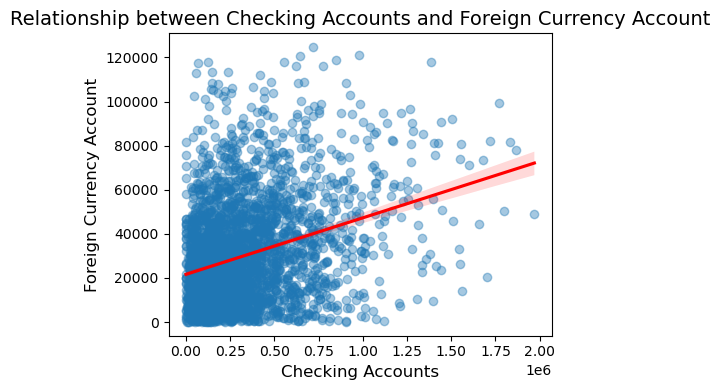

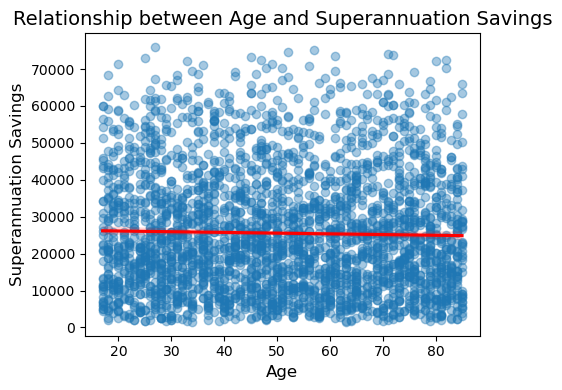

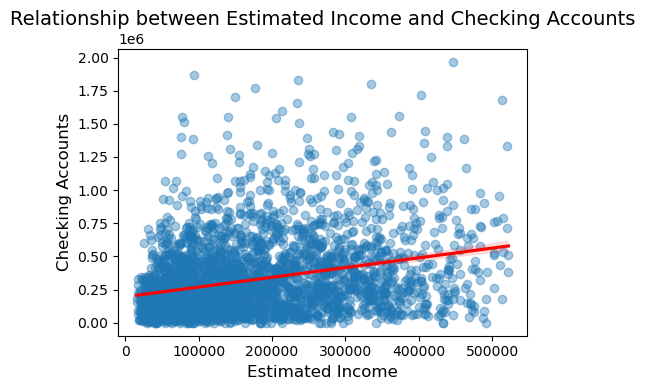

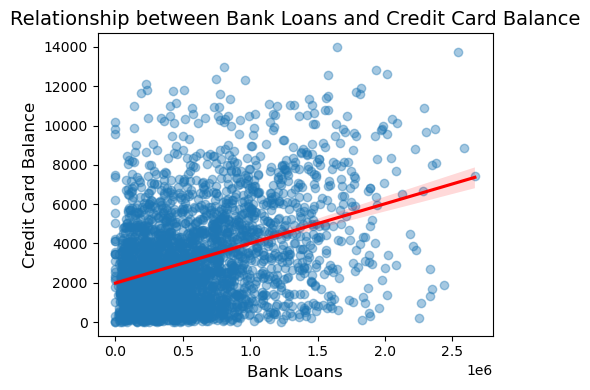

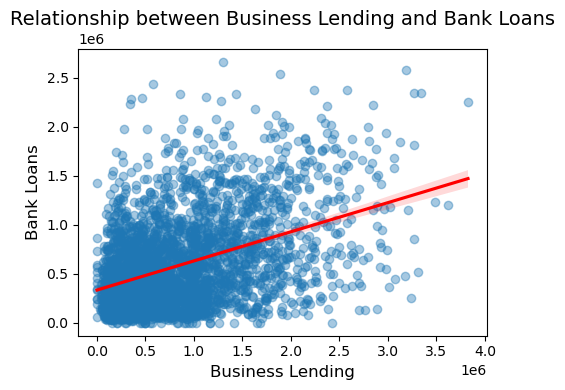

In [57]:
pairs_to_plot = [
    ('Bank Deposits', 'Saving Accounts'),
    ('Checking Accounts', 'Saving Accounts'),
    ('Checking Accounts', 'Foreign Currency Account'),
    ('Age', 'Superannuation Savings'),
    ('Estimated Income', 'Checking Accounts'),
    ('Bank Loans', 'Credit Card Balance'),
    ('Business Lending', 'Bank Loans'),
]

for xcol, ycol in pairs_to_plot:
    plt.figure(figsize=(5,4))
    sns.regplot( data = df, x= xcol, y= ycol, scatter_kws={'alpha': 0.4}, line_kws ={'color': 'red'})
    plt.title(f'Relationship between {xcol} and {ycol}', fontsize = 14)
    plt.xlabel(xcol, fontsize = 12)
    plt.ylabel(ycol, fontsize = 12)
    plt.tight_layout()
    plt.show()

sns.regplot: A Seaborn function that draws a scatter plot and automatically calculates and overlays a linear regression line (trendline) to show the relationship between variables.

scatter_kws={'alpha': 0.4}: Modifies the data points. Setting alpha to 0.4 makes the dots 40% opaque (semi-transparent). This is incredibly helpful for seeing clusters where many dots overlap.

line_kws={'color': 'red'}: Colors the trendline red so it stands out against the dots.

### Insights

1. Savings Account and Bank Deposit
   The positive correlation between these two parameters shows that when the bank deposit tends to increase, the amount in the savings account also increases. The heaviest concentration of points are around 0.0 and 1.5. This suggests that vast majority of the bank's customer base consists of smaller, everyday accounts rather than high-net-worth individuals.

2. Savings Account and Checking Account
   There is a gradual positive correlation between checking and saving balances, shown by the upward-sloping red regression line. Generally, as checking account balances increase, saving balances tend to rise as well.

   The data splits into a striking "V-shape" or dual-wing pattern starting from the bottom-left corner, revealing two completely different customer behaviors:

   The "Savers" Wing (Top Left): A massive cluster of customers keeps relatively low balances in their checking accounts (under 0.75) but amasses significantly higher amounts in their saving accounts (up to 1.75). These individuals likely transfer excess funds into savings immediately to earn interest.

   The "Transactional" Wing (Bottom Right): Another distinct group maintains high checking account balances (stretching all the way out to 2.00) but keeps very little money in their saving accounts (under 0.50). These customers prioritize high liquidity, using their accounts primarily for transactional purposes or business operations rather than long-term saving.

In [ ]:
pd.to_csv('Banking_dataset.csv')